# BioASQ training EDA

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [ ]:
with open("...\\trainining14b.json", "r") as f:
    data=json.load(f)

In [5]:
print(f"Total questions: {len(data['questions'])}")
data=data['questions']
data[0].keys()

Total questions: 5729


dict_keys(['body', 'documents', 'ideal_answer', 'concepts', 'type', 'id', 'snippets'])

In [12]:
counts={}
for key in data:
    if key['type'] not in counts:
        counts[key['type']]=0
    counts[key['type']]+=1

print(counts)

{'summary': 1363, 'list': 1130, 'yesno': 1541, 'factoid': 1695}


In [17]:
# percentagens

total= sum(counts.values())

print(f"Summary questions: {counts['summary']/total}")
print(f"Yesno questions: {counts['yesno']/total}")
print(f"Factoid questions: {counts['factoid']/total}")
print(f"List questions: {counts['list']/total}")

Summary questions: 0.23791237563274567
Yesno questions: 0.2689823703962297
Factoid questions: 0.2958631523826148
List questions: 0.19724210158840985


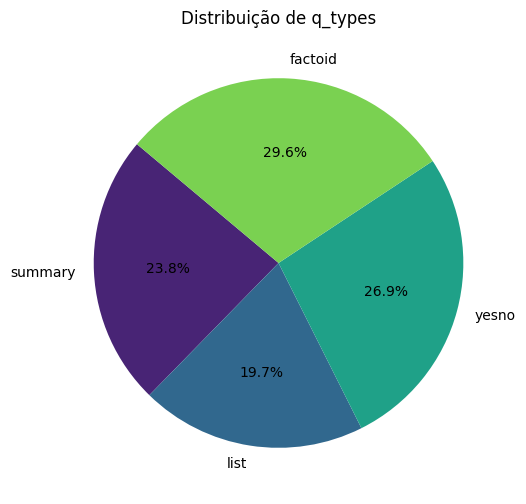

In [34]:
labels=counts.keys()
values=counts.values()
color=plt.get_cmap('viridis')(np.linspace(0.1, 0.8, len(labels)))

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=color)
plt.title("Distribuição de q_types")

plt.show()

In [7]:
df=pd.DataFrame({'n_docs':[len(d['documents']) for d in data], 'n_snips': [len(d['snippets']) for d in data]})

df_docs=df['n_docs'].value_counts().sort_index().reset_index()

df_docs.columns=['Nº docs', 'Qtd de perguntas']

df_docs['%Total']= (df_docs['Qtd de perguntas']/len(data))*100

print(df_docs.to_string(index=False))

 Nº docs  Qtd de perguntas    %Total
       1              1150 20.073311
       2               394  6.877291
       3               401  6.999476
       4               340  5.934718
       5               316  5.515797
       6               259  4.520859
       7               219  3.822657
       8               222  3.875022
       9               195  3.403735
      10               194  3.386280
      11               194  3.386280
      12               140  2.443707
      13               138  2.408797
      14               110  1.920056
      15               119  2.077151
      16               119  2.077151
      17               114  1.989876
      18                95  1.658230
      19                67  1.169489
      20                74  1.291674
      21                84  1.466224
      22                58  1.012393
      23                64  1.117123
      24                56  0.977483
      25                49  0.855298
      26                44  0.768022
 

In [9]:
print("---Estatísticas Gerais---")
print(df.describe().loc[['mean', 'min', '50%', 'max']])

---Estatísticas Gerais---
          n_docs     n_snips
mean   10.735905   13.974167
min     1.000000    1.000000
50%     7.000000    9.000000
max   157.000000  121.000000


In [48]:
#de onde vêm os snippets
start, end={}, {}

for d in data:
    snippets=d['snippets']
    for sec in snippets:
        if sec['beginSection'] not in start:
            start[sec['beginSection']]=0
        start[sec['beginSection']]+=1

        if sec['endSection'] not in end:
            end[sec['endSection']]=0
        end[sec['endSection']]+=1
    
print("begin sections:", start)
print("\n end sections:", end)
    

begin sections: {'abstract': 67829, 'title': 8154, 'sections.0': 4075}

 end sections: {'abstract': 67829, 'title': 8154, 'sections.0': 4075}
